## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load & Eksplorasi Dataset

Pastikan file `Mall_Customers.csv` berada di folder yang sama dengan notebook ini.
Dataset berisi data pelanggan mall: ID, Gender, Age, Annual Income (k$), dan Spending Score (1-100).

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print("Jumlah baris & kolom:", df.shape)
df.head()


Jumlah baris & kolom: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
# Cek missing value
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 3. Visualisasi Data Awal

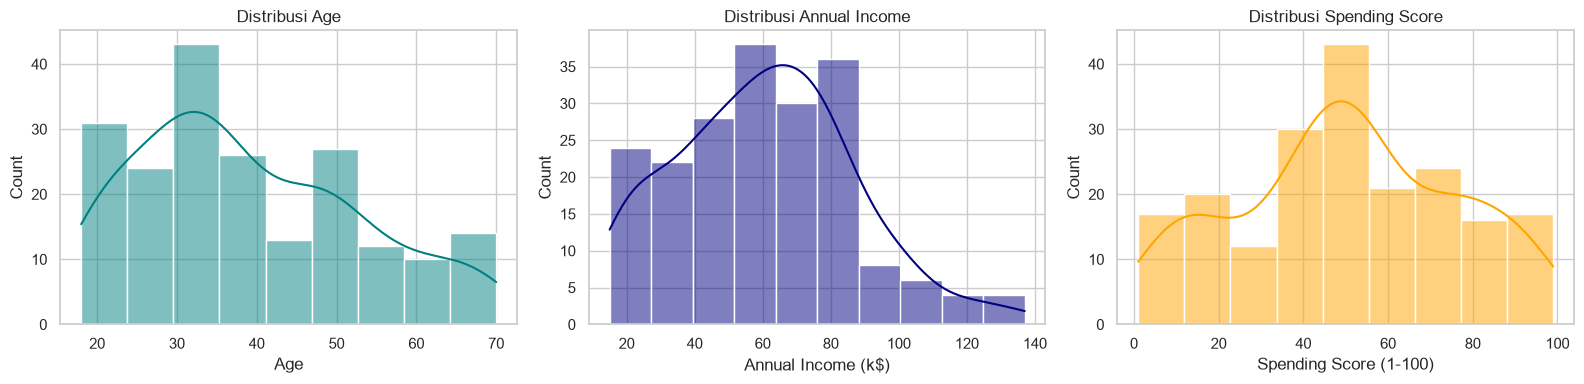

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribusi Age")

sns.histplot(df["Annual Income (k$)"], kde=True, ax=axes[1], color="navy")
axes[1].set_title("Distribusi Annual Income")

sns.histplot(df["Spending Score (1-100)"], kde=True, ax=axes[2], color="orange")
axes[2].set_title("Distribusi Spending Score")

plt.tight_layout()
plt.show()


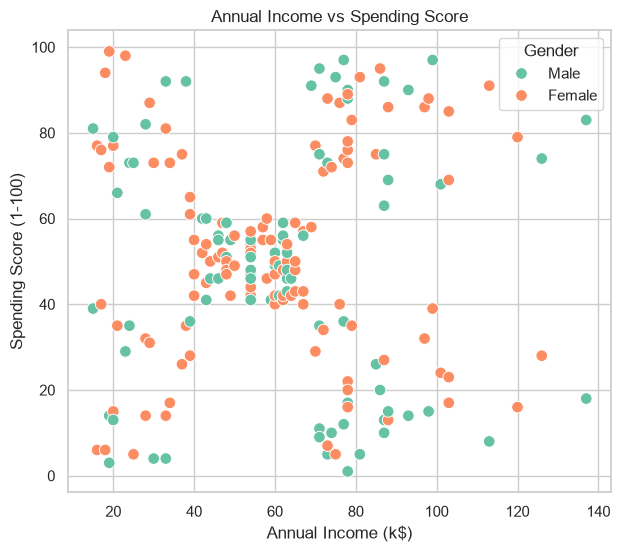

In [7]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                 hue="Gender", palette="Set2", s=70)
plt.title("Annual Income vs Spending Score")
plt.show()


## 4. Preprocessing (Feature Selection & Scaling)

Untuk clustering, fitur yang paling relevan dan mudah divisualisasikan adalah:
- **Annual Income (k$)**
- **Spending Score (1-100)**

Fitur numerik perlu di-*scale* (standardisasi) agar tidak ada fitur yang mendominasi perhitungan jarak (Euclidean distance) yang digunakan dalam hierarchical clustering.

In [8]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Contoh data sebelum scaling:\n", X[:5])
print("\nContoh data setelah scaling:\n", X_scaled[:5])


Contoh data sebelum scaling:
 [[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]

Contoh data setelah scaling:
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## 5. Membuat Dendrogram

Dendrogram digunakan untuk melihat struktur hierarki penggabungan cluster dan membantu menentukan jumlah cluster optimal.
Linkage method yang digunakan adalah **'ward'**, karena meminimalkan variansi di dalam tiap cluster.

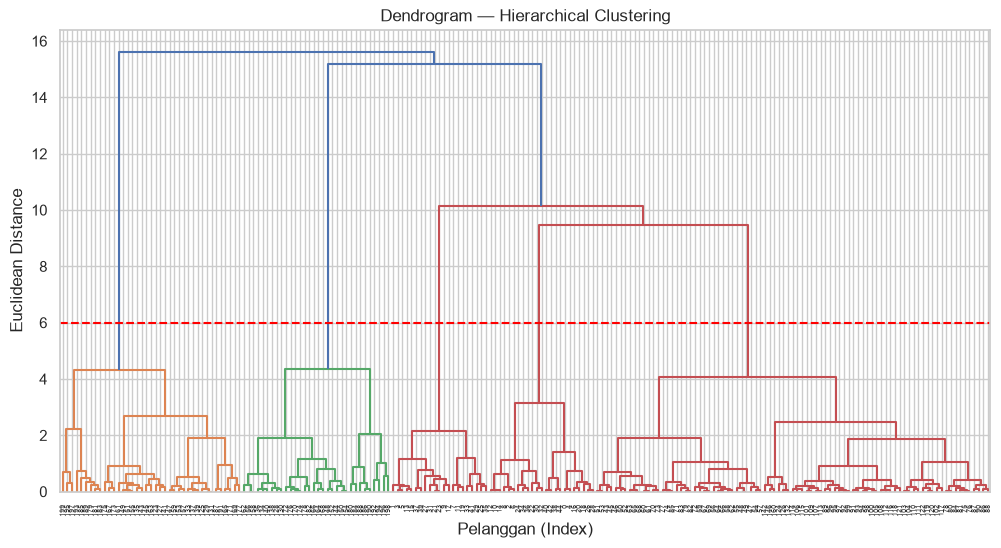

In [9]:
plt.figure(figsize=(12, 6))
Z = linkage(X_scaled, method="ward")
dendrogram(Z)
plt.title("Dendrogram — Hierarchical Clustering")
plt.xlabel("Pelanggan (Index)")
plt.ylabel("Euclidean Distance")
plt.axhline(y=6, color="red", linestyle="--")  # garis bantu pemotongan cluster
plt.show()


**Cara membaca dendrogram:**
Tarik garis horizontal (garis putus-putus merah pada contoh di atas) pada jarak vertikal terbesar yang belum terpotong oleh garis horizontal manapun. Jumlah garis vertikal yang terpotong oleh garis tersebut = jumlah cluster optimal. Pada dataset ini, biasanya didapatkan **5 cluster** yang paling representatif.

## 6. Menentukan Jumlah Cluster Optimal (Validasi dengan Silhouette Score)

k=2 -> Silhouette Score: 0.3842
k=3 -> Silhouette Score: 0.4610
k=4 -> Silhouette Score: 0.4926
k=5 -> Silhouette Score: 0.5538
k=6 -> Silhouette Score: 0.5387
k=7 -> Silhouette Score: 0.5198
k=8 -> Silhouette Score: 0.4309
k=9 -> Silhouette Score: 0.4377
k=10 -> Silhouette Score: 0.4339


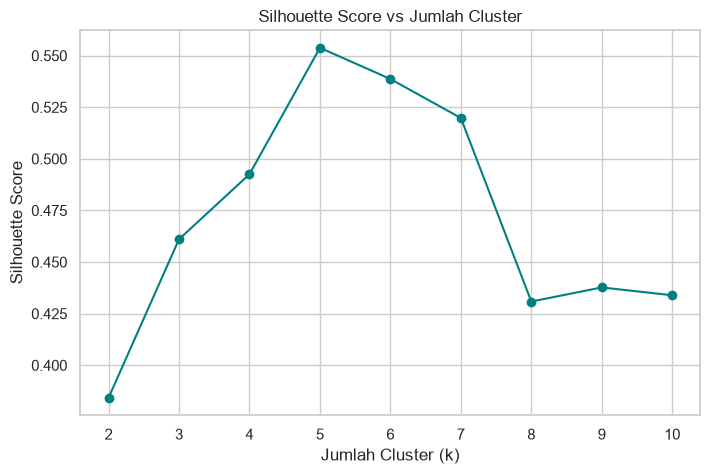

In [10]:
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k} -> Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker="o", color="teal")
plt.title("Silhouette Score vs Jumlah Cluster")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.show()


## 7. Agglomerative Clustering

Berdasarkan dendrogram dan silhouette score, kita gunakan **k = 5** cluster 

In [11]:
n_clusters = 5

hc = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
df["Cluster"] = hc.fit_predict(X_scaled)

print("Jumlah anggota tiap cluster:")
print(df["Cluster"].value_counts().sort_index())
df.head()


Jumlah anggota tiap cluster:
Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


## 8. Visualisasi Hasil Clustering

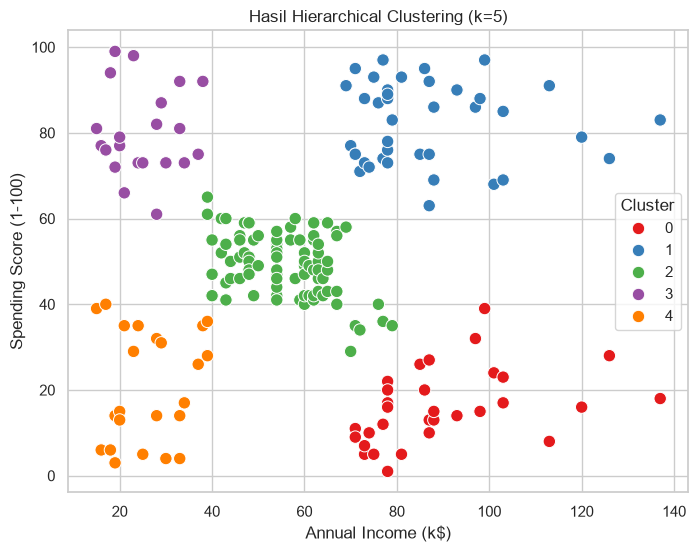

In [12]:
plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set1", n_colors=n_clusters)

sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Cluster", palette=palette, s=80, legend="full"
)
plt.title(f"Hasil Hierarchical Clustering (k={n_clusters})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()


## 9. Analisis & Profiling Tiap Cluster

Melihat karakteristik rata-rata (Age, Annual Income, Spending Score) pada setiap cluster untuk memberi label/insight bisnis.

In [13]:
cluster_profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_profile["Jumlah Pelanggan"] = df["Cluster"].value_counts().sort_index()
cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),Jumlah Pelanggan
Cluster,,,,
0,41.0,89.4,15.6,32
1,32.7,86.5,82.1,39
2,42.5,55.8,49.1,85
3,25.3,25.1,80.0,21
4,45.2,26.3,20.9,23


C:\Users\Dell\AppData\Local\Temp\ipykernel_17596\109278926.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="Age", palette=palette, ax=axes[0])
C:\Users\Dell\AppData\Local\Temp\ipykernel_17596\109278926.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="Annual Income (k$)", palette=palette, ax=axes[1])
C:\Users\Dell\AppData\Local\Temp\ipykernel_17596\109278926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="Spending Score (1-100)", palette=palette, ax=axes[2])


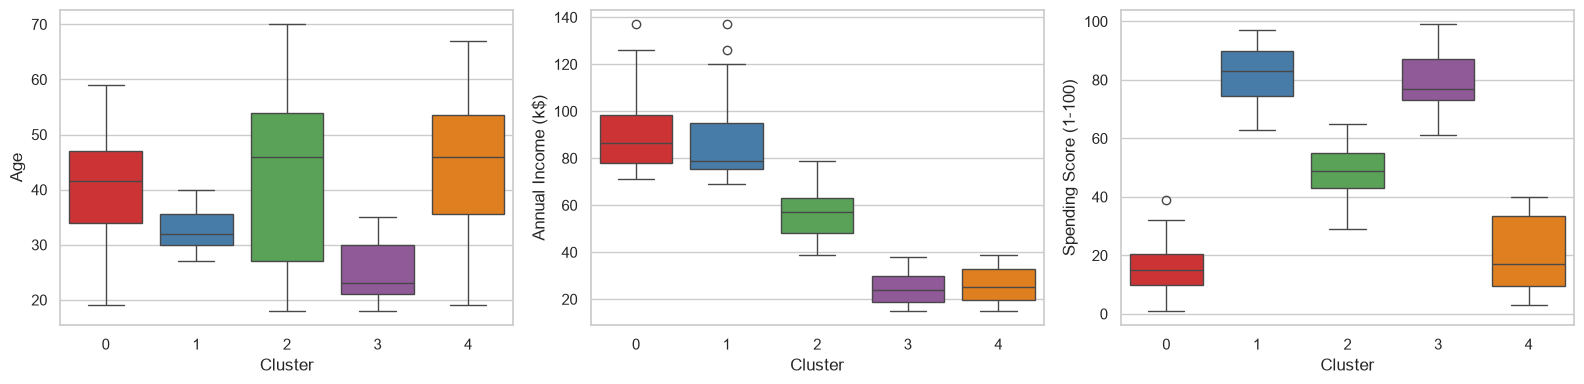

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x="Cluster", y="Age", palette=palette, ax=axes[0])
sns.boxplot(data=df, x="Cluster", y="Annual Income (k$)", palette=palette, ax=axes[1])
sns.boxplot(data=df, x="Cluster", y="Spending Score (1-100)", palette=palette, ax=axes[2])
plt.tight_layout()
plt.show()


**Contoh interpretasi (sesuaikan dengan hasil Anda):**
- **Cluster 0:** Income tinggi, Spending Score rendah → pelanggan hemat/konservatif.
- **Cluster 1:** Income tinggi, Spending Score tinggi → pelanggan premium/target utama promosi.
- **Cluster 2:** Income rendah, Spending Score tinggi → pelanggan impulsif.
- **Cluster 3:** Income rendah, Spending Score rendah → pelanggan pasif.
- **Cluster 4:** Income & Spending Score sedang → pelanggan rata-rata/umum.


## 10. Kesimpulan

- Hierarchical Clustering (Agglomerative, linkage='ward') berhasil mengelompokkan 200 pelanggan mall ke dalam beberapa segmen berdasarkan Annual Income dan Spending Score.
- Dendrogram dan Silhouette Score digunakan untuk membantu menentukan jumlah cluster yang optimal.
- Hasil segmentasi ini dapat digunakan oleh tim marketing untuk merancang strategi promosi yang lebih tepat sasaran pada masing-masing segmen pelanggan.

> Catatan: Anda bisa mengganti fitur yang digunakan (misalnya menambahkan `Age`) atau mengganti `linkage` method (`single`, `complete`, `average`, `ward`) untuk melihat perbedaan hasil clustering.
